#**🧠Taller Práctico: Clasificación de Riesgo Crediticio con Perceptrón**
###**❗Contexto del Problema**
Una entidad financiera desea automatizar la aprobación de créditos pre-aprobados. Se cuenta con dos variables de entrada:

* **Puntaje Crediticio** (Normalizado de 0 a 1).
* **Ratio de Ahorro** (Dinero ahorrado vs ingresos anuales).

El objetivo es entrenar un **Perceptrón Simple** en Keras para que aprenda la frontera de decisión que separa a los clientes de "Bajo Riesgo" (Clase 1) de los de "Alto Riesgo" (Clase 0).

##**1️⃣Paso 1: Preparación del Entorno**
Cargamos las librerías necesarias y generamos un dataset sintético que represente este escenario.

In [22]:
# Se importa tensorflow y sus módulos para cosntruir redes neuronales.
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

# Se importa las librerías para manejo numérico y visualización.
import numpy as np
import matplotlib.pyplot as plt

# Se importan las herramientas para generar datasets sintéticos.
from sklearn.datasets import make_moons, make_blobs

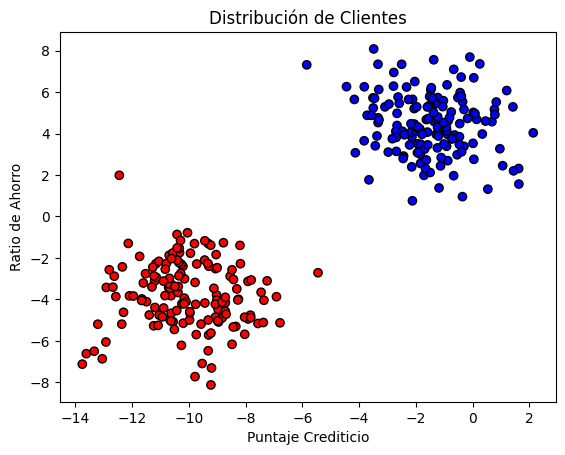

In [23]:
# Generación del dataset, se crean 300 clientes simulados con 2 características: puntaje crediticio y ratio de ahorro.
X, y = make_blobs(
  n_samples=300,    # n_samples: cantidad de ejemplos.
  centers=2,        # centers: cantidad de clases.
  n_features=2,     # n_features: cantidad de variables de entrada.
  cluster_std=1.5,  # cluster_std: dispersión de los datos (ruido).
  random_state=1    # random_state: asegura reproducibilidad.
)

# Visualización de los datos generados.
# Se grafican los puntos (clientes) para observar cómo están distribuidos.
# Cada color representa una clase (0 = alto riesgo, 1 = bajo riesgo).
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
plt.xlabel("Puntaje Crediticio")
plt.ylabel("Ratio de Ahorro")
plt.title("Distribución de Clientes")
plt.show()

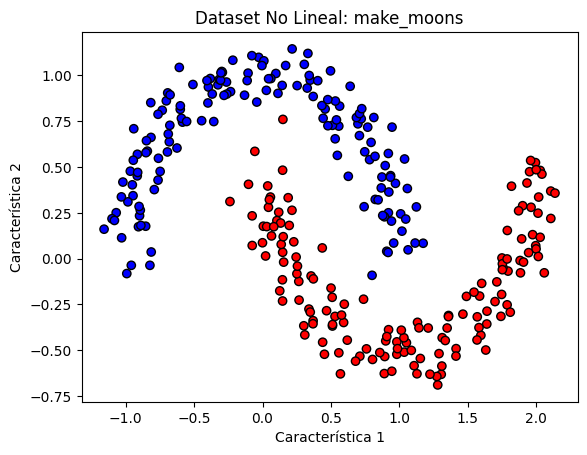

In [16]:
# EJECUTAR CELDA PARA DESAFIO 3: No Linealidad.
"""
# Generación del dataset con forma de dos lunas entrelazadas.
X, y = make_moons(
  n_samples=300,  # Cantidad de ejemplos (puntos).
  noise=0.1,      # Agrega dispersión para simular datos reales.
  random_state=1  # Asegura que siempre se generen los mismos datos.
)

# Visualización de los datos.
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')

# Etiquetas del gráfico.
plt.xlabel("Característica 1")
plt.ylabel("Característica 2")
plt.title("Dataset No Lineal: make_moons")

# Mostrar gráfico
plt.show()
"""

###**📌Estado actual**
* 📦 Se preparó el entorno con las librerías necesarias.
* 🧪 Se generó un dataset sintético de clientes con dos variables.
* 📊 Se visualizó la separación inicial entre clases de riesgo.

---

####**🔜 Próximo paso:**
Se comenzará con la preparación del modelo de perceptrón simple, definiendo la estructura de la red neuronal que aprenderá a clasificar los clientes en alto o bajo riesgo.

##**2️⃣Paso 2: Definición de la Arquitectura (Misión del Alumno)**
Debes definir un modelo secuencial que represente un Perceptrón Simple. Recuerda que para una clasificación binaria, la salida debe pasar por una función que comprima el valor entre 0 y 1.

**💡Guía Técnica:**
* Usa una capa Dense.
* Como es un Perceptrón de una sola capa, units debe ser igual a 1.
* El input_shape debe coincidir con la cantidad de variables de entrada (2).

In [24]:
# Definición del modelo secuencial.
# Un perceptrón simple es la red neuronal más básica.
# Una sola capa, ua sola neurona y activavión sigmoide para clasificación binaria.
model = Sequential([
  # Capa Dense:
  # units=1: una sola neurona (salida binaria).
  # input_shape=(2,): dos variables de entrada.
  # activation='sigmoid': comprime la salida entre 0 y 1.
  Dense(units=1, input_shape=(2,), activation='sigmoid')
])

In [18]:
# EJECUTAR CELDA PARA DESAFIO 2: Regularización L2.
"""
Dense(
  units=1,
  input_shape=(2,),
  activation='sigmoid',

  # Regularización L2:
  # Penaliza pesos grandes para evitar overfitting.
  kernel_regularizer='l2'
)
"""

<Dense name=dense_2, built=False>

###**📌Estado actual**
* 📊 Ya se generaron y visualizaron los datos de clientes
* 🧠 Se definió la arquitectura del modelo (Perceptrón Simple)
* ⚙️ El modelo cuenta con una única neurona con activación sigmoide
* 🎯 El objetivo ahora es preparar el modelo para su entrenamiento

---

####**🔜 Próximo paso:**
Se compilará el modelo definiendo la función de pérdida y el optimizador para que pueda aprender a clasificar correctamente los clientes.

##**3️⃣Paso 3: Compilación del Sistema**
Para que el modelo aprenda, debemos definir el Optimizador (que gestiona la Tasa de Aprendizaje) y la Función de Pérdida (que mide el error).

💡**Ayuda Sugerida:**
* Para clasificación binaria, la pérdida estándar es binary_crossentropy.
* Experimenta con diferentes valores en learning_rate (prueba con 0.01, 0.1 y 0.5).

In [25]:
# Compilación del modelo, acá se define:
# Optimizador: cómo el modelo ajusta sus pesos.
# Learning rate: tamaño de los ajustes en cada iteración.
# Función de pérdida: para medir qué tan mal está precidiendo.
model.compile(

  # Optimizador SGD (Gradient Descent Estocástico).
  # learning_rate controla qué tan grande es el "paso" de aprendizaje.
  optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),

  # Función de pérdidad para clasificación binaria.
  # Mide la diferencia entre la predicción (0-1) y el valor real (0 o 1).
  loss='binary_crossentropy',

  # Métrica opcional para monitorear el desempeño.
  metrics=["accuracy"]
)

###**📌Estado actual**
* 🧠 Se definió la estructura del perceptrón simple.
* ⚙️ Se configuró el modelo para aprendizaje.
* 📉 Se eligió la función de pérdida adecuada para clasificación binaria.
* 🚀 Se estableció el optimizador SGD con tasa de aprendizaje ajustable.

---

####**🔜Próximo paso:**
Entrenar el modelo con los datos generados para que aprenda a separar clientes de alto y bajo riesgo.

##**4️⃣ Paso 4: Entrenamiento y Regularización**
Es momento de ajustar los pesos. Vamos a entrenar el modelo, pero esta vez, presta atención a cómo el número de épocas afecta el resultado.

**📍Instrucciones:**
* Ejecuta el método .fit().
* Prueba configurar el entrenamiento con 50 épocas.

In [26]:
# Entrenamiento del Modelo
# Acá el perceptrón ajusta sus pesos internos para aprender a separar las dos clases.
history = model.fit(

  # Datos de entrada y etiquetas (clases).
  X, y,

  # Número de épocas.
  # Cada época es una pasada completa sobre los datos.
  epochs=50,

  # verbose=1 muestra el progreso del entrenamiento.
  verbose=1
)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5800 - loss: 1.4634  
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9967 - loss: 0.0787 
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0422 
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0305 
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0249 
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0213 
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0188 
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0169 
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0155 
Epoch 10/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0143 
Epoch 11/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0134 
Epoch 12/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy:

###**📌Estado actual**
* 🧠 Se definió y compiló el modelo perceptrón.
* ⚙️ Se configuró el entrenamiento con 50 épocas.
* 📈 El modelo comenzó a ajustar sus pesos internos.
* 🔁 Se realizaron múltiples iteraciones sobre los datos para mejorar la predicción.

---

####**🔜 Próximo paso:**
Analizar cómo evolucionó el aprendizaje y evaluar el desempeño del modelo (curva de error y precisión).

##**5️⃣Paso 5: Evaluación de Resultados**
Una vez entrenado, utilizaremos el siguiente bloque para visualizar la Frontera de Decisión que tu modelo ha construido.

1024/1024 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


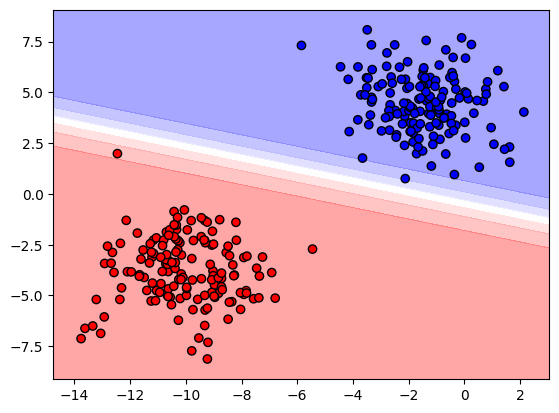

In [27]:
# Visualización de la frontera de decisión.
# Esta función permite ver cómoo el modleo separa las clases.
def plot_frontier(X, y, model):

  # Se definen los límites del gráfico según los datos.
  x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
  y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

  # Se crea una grilla de puntos para evaluar al modelo.
  xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.1),
    np.arange(y_min, y_max, 0.1)
  )

  # Se predice la clase para cada punto de la grilla.
  Z = model.predict(np.c_[xx.ravel(), yy.ravel()])

  # Se reorganiza la salida para que coincida con la grilla.
  Z = Z.reshape(xx.shape)

  # Se dibuja la frontera de decisión.
  plt.contourf(xx, yy, Z, alpha=0.4, cmap='bwr')

  # Se dibujan los datos reales.
  plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='bwr')
  plt.show()

# Se ejcuta la función para la visualización.
plot_frontier(X, y, model)

###**📌Estado actual**
* 🧠 El perceptrón fue entrenado con datos de clientes.
* 📉 Se aprendió una frontera de decisión entre alto y bajo riesgo.
* 🎯 Se visualizó cómo el modelo separa ambas clases en el plano.
* 📊 Se validó el comportamiento del modelo de forma gráfica.

---

####**📊 Interpretación de resultados (frontera de decisión)**
* 🔵 Zona azul: el modelo clasifica como Clase 1 (bajo riesgo).
* 🔴 Zona roja: el modelo clasifica como Clase 0 (alto riesgo).
* ⚪ Zona intermedia: es la frontera de decisión.

---

####**🔍Se observa que:**
* 📈 El modelo logró encontrar una separación lineal entre ambas clases.
* 🎯 Los puntos azules y rojos están mayormente bien separados.
* ⚠️ Algunos puntos cercanos a la frontera pueden estar mal clasificados (zona de incertidumbre natural).

---

####**🏁 Conclusión:**
El perceptrón simple es capaz de aprender una separación lineal básica entre clases, funcionando como base para modelos más complejos de redes neuronales.

##**🏆Desafíos Extra**

---

**1️⃣Impacto del Sesgo:** Si imprimes los pesos del modelo con model.get_weights().
* ¿cuál es el valor del Bias?
* ¿Qué pasaría si fuera cero?

---

**2️⃣Regularización:** Regresa al Paso 2 e intenta agregar kernel_regularizer='l2' dentro de la capa Dense.
* ¿Notas algún cambio en la suavidad de la frontera o en el valor de los pesos?

---

**3️⃣No Linealidad:** Cambia el generador de datos por make_moons(n_samples=300, noise=0.1).

* ¿Es capaz el Perceptrón de una sola capa de separar estos datos? Justifica basándote en la teoría de Separabilidad Lineal.

In [28]:
# DESAFIO 1: Impacto del Sesgo.
model.get_weights()

[array([[-0.4516416],
        [-1.6020381]], dtype=float32),
 array([-0.6866945], dtype=float32)]

###**🧠Desafío 1 - Bias**
El bias es el segundo elementos: array([-0.65792894], dtype=float32)]. Entonces el Bias es aproximadamente -0.658

* El **bias** obtenido en el modelo permite desplazar la frontera de decisión, dándole mayor flexibilidad para adaptarse a los datos. Si el **bias** fuera cero, la frontera estaría forzada a pasar por el origen, lo que limita la capacidad del modelo para separar correctamente los datos y puede reducir su rendimiento.

---

###**🌊Desafío 2 - Regularización L2**
* Al agregar **regularización L2**, los **pesos** del modelo disminuyen en magnitud y la **frontera de decisión** se vuelve más suave. Esto ocurre porque el modelo es penalizado cuando usa valores de **pesos** grandes, lo que lo obliga a buscar soluciones más simples y estables. Como resultado, el modelo reduce el **sobreajuste** y generaliza mejor a los datos.

---

###**🌙Desafío 3 - No Linealidad**
* Con **make_moons**, los datos no son linealmente separables, por lo que un **perceptrón** de una sola capa no puede clasificarlos correctamente. Esto ocurre porque solo puede aprender fronteras rectas, mientras que este dataset requiere una frontera curva. En cambio, con **make_blobs**, los datos sí pueden separarse con una línea recta, por lo que el **perceptrón** funciona bien.